# DatasetCollection population and expression feature spaces

This notebook creates toy cell-level data for multiple datasets, then calculates dataset-level feature spaces with `DatasetCollection`. The toy data has ten cell types grouped into broader immune categories, a T-cell proportion gradient across datasets, and toy gene expression that lets us calculate a CD8 T-cell category signature across dataset space.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from anndata import AnnData

import celldega as dega

In [2]:
rng = np.random.default_rng(42)

cell_types = [
    "CD4 T",
    "CD8 T",
    "Treg",
    "B cell",
    "Plasma cell",
    "NK",
    "Monocyte",
    "Macrophage",
    "Dendritic cell",
    "Neutrophil",
]
immune_group = {
    "CD4 T": "T/NK",
    "CD8 T": "T/NK",
    "Treg": "T/NK",
    "NK": "T/NK",
    "B cell": "B/plasma",
    "Plasma cell": "B/plasma",
    "Monocyte": "myeloid",
    "Macrophage": "myeloid",
    "Dendritic cell": "myeloid",
    "Neutrophil": "granulocyte",
}

genes = [
    "CD3D",
    "CD3E",
    "TRAC",
    "GZMB",
    "IFNG",
    "MS4A1",
    "CD79A",
    "MZB1",
    "LYZ",
    "S100A8",
    "FCGR3A",
    "ITGAX",
]
gene_to_idx = {gene: idx for idx, gene in enumerate(genes)}

condition_templates = {
    "inflamed": np.array([5, 6, 2, 2, 1, 3, 5, 4, 3, 4], dtype=float),
    "cold": np.array([2, 2, 1, 4, 3, 1, 2, 2, 1, 1], dtype=float),
    "myeloid_rich": np.array([2, 2, 1, 1, 1, 1, 6, 7, 4, 2], dtype=float),
}
t_cell_boost = np.array([10, 12, 4, 0, 0, 3, 0, 0, 0, 0], dtype=float)


def expression_mean(cell_type, sample_progress):
    mean = np.full(len(genes), 0.08, dtype=float)

    if cell_type in {"CD4 T", "CD8 T", "Treg", "NK"}:
        mean[[gene_to_idx["CD3D"], gene_to_idx["CD3E"], gene_to_idx["TRAC"]]] += [2.2, 2.0, 2.4]
    if cell_type == "CD8 T":
        mean[[gene_to_idx["GZMB"], gene_to_idx["IFNG"]]] += [1.2 + 3.0 * sample_progress, 0.7 + 2.2 * sample_progress]
    if cell_type == "NK":
        mean[[gene_to_idx["GZMB"], gene_to_idx["FCGR3A"]]] += [1.6, 1.8]
    if cell_type == "B cell":
        mean[[gene_to_idx["MS4A1"], gene_to_idx["CD79A"]]] += [2.4, 2.2]
    if cell_type == "Plasma cell":
        mean[[gene_to_idx["MZB1"], gene_to_idx["CD79A"]]] += [3.2, 1.0]
    if cell_type in {"Monocyte", "Macrophage", "Dendritic cell", "Neutrophil"}:
        mean[[gene_to_idx["LYZ"], gene_to_idx["S100A8"]]] += [2.3, 1.8]
    if cell_type == "Dendritic cell":
        mean[gene_to_idx["ITGAX"]] += 2.4
    if cell_type == "Macrophage":
        mean[gene_to_idx["FCGR3A"]] += 1.2

    return mean


rows = []
expression_rows = []
n_samples = 12
for sample_idx in range(n_samples):
    sample_id = f"sample_{sample_idx:02d}"
    patient_id = f"patient_{sample_idx // 2:02d}"
    condition = ["cold", "myeloid_rich", "inflamed"][sample_idx % 3]
    sample_progress = sample_idx / (n_samples - 1)
    n_cells = int(rng.integers(500, 900))

    alpha = condition_templates[condition] + sample_progress * t_cell_boost
    alpha = alpha * rng.uniform(0.9, 1.1, size=len(cell_types))
    proportions = rng.dirichlet(alpha)
    counts = rng.multinomial(n_cells, proportions)

    for cell_type, count in zip(cell_types, counts, strict=False):
        for _ in range(count):
            rows.append(
                {
                    "sample_id": sample_id,
                    "patient_id": patient_id,
                    "condition": condition,
                    "sample_order": sample_idx,
                    "t_cell_gradient": sample_progress,
                    "cell_type": cell_type,
                    "immune_group": immune_group[cell_type],
                }
            )
            expression_rows.append(rng.poisson(expression_mean(cell_type, sample_progress)))

obs = pd.DataFrame(rows)
obs.index = [f"cell_{i:05d}" for i in range(len(obs))]
X = np.vstack(expression_rows).astype(float)

adata = AnnData(
    X=X,
    obs=obs,
    var=pd.DataFrame(index=genes),
)
adata

AnnData object with n_obs × n_vars = 8429 × 12
    obs: 'sample_id', 'patient_id', 'condition', 'sample_order', 't_cell_gradient', 'cell_type', 'immune_group'

In [3]:
adata.obs.head()

,sample_id,patient_id,condition,sample_order,t_cell_gradient,cell_type,immune_group
cell_00000,sample_00,patient_00,cold,0,0.0,CD4 T,T/NK
cell_00001,sample_00,patient_00,cold,0,0.0,CD4 T,T/NK
cell_00002,sample_00,patient_00,cold,0,0.0,CD4 T,T/NK
cell_00003,sample_00,patient_00,cold,0,0.0,CD4 T,T/NK
cell_00004,sample_00,patient_00,cold,0,0.0,CD4 T,T/NK


In [4]:
adata.obs['sample_id'].value_counts()

sample_id
sample_05    866
sample_02    841
sample_01    809
sample_08    788
sample_11    783
sample_10    758
sample_07    701
sample_09    654
sample_03    627
sample_06    548
sample_00    535
sample_04    519
Name: count, dtype: int64

In [5]:
dset = dega.dataset.DatasetCollection(
    adata,
    dataset_col="sample_id",
    obs_columns=["patient_id", "condition", "sample_order", "t_cell_gradient"],
)

dset.obs.head()

,sample_id,n_cells,patient_id,condition,sample_order,t_cell_gradient
sample_id,,,,,,
sample_00,sample_00,535,patient_00,cold,0,0.000000
sample_01,sample_01,809,patient_00,myeloid_rich,1,0.090909
sample_02,sample_02,841,patient_01,inflamed,2,0.181818
sample_03,sample_03,627,patient_01,cold,3,0.272727
sample_04,sample_04,519,patient_02,myeloid_rich,4,0.363636


In [6]:
dset.calc_population(
    adata,
    category="cell_type",
    modality_name="cell_type_population",
    output="proportion",
)

dset.calc_population(
    adata,
    category="immune_group",
    modality_name="immune_group_population",
    output="proportion",
)

cell_type_space = dset.mod["cell_type_population"]
immune_group_space = dset.mod["immune_group_population"]

list(dset.mod)


['cell_type_population', 'immune_group_population']

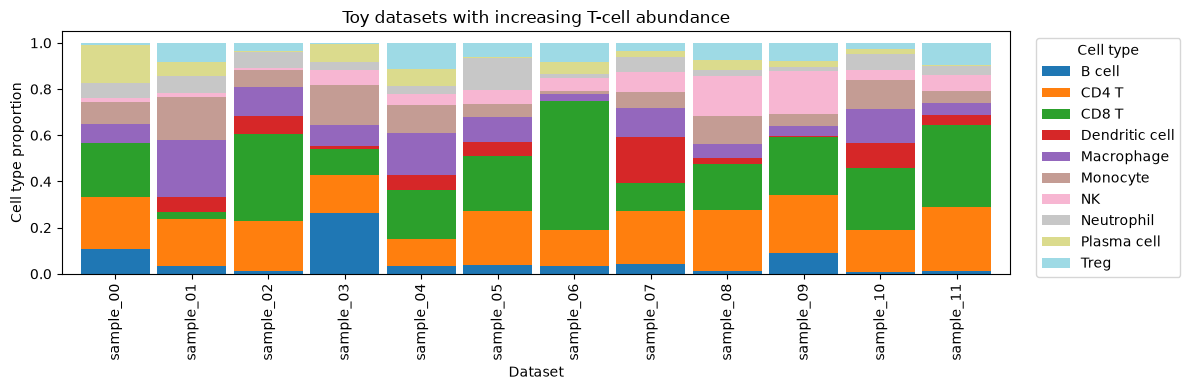

In [7]:
ordered_samples = dset.obs.sort_values("sample_order").index
cell_type_proportions = cell_type_space.to_df().loc[ordered_samples]

ax = cell_type_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4),
    colormap="tab20",
    width=0.9,
)
ax.set_xlabel("Dataset")
ax.set_ylabel("Cell type proportion")
ax.set_title("Toy datasets with increasing T-cell abundance")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

In [8]:
cell_type_space.to_df().loc[ordered_samples].head()

cell_type,B cell,CD4 T,CD8 T,Dendritic cell,Macrophage,Monocyte,NK,Neutrophil,Plasma cell,Treg
sample_id,,,,,,,,,,
sample_00,0.108411,0.222430,0.233645,0.001869,0.082243,0.097196,0.016822,0.061682,0.168224,0.007477
sample_01,0.035847,0.202719,0.029666,0.063041,0.249691,0.186650,0.014833,0.072930,0.063041,0.081582
sample_02,0.014269,0.215220,0.374554,0.079667,0.124851,0.073722,0.010702,0.068966,0.003567,0.034483
sample_03,0.263158,0.164274,0.114833,0.011164,0.090909,0.172249,0.065391,0.033493,0.079745,0.004785
sample_04,0.032755,0.119461,0.211946,0.061657,0.183044,0.121387,0.050096,0.030829,0.077071,0.111753


In [9]:
target_cell_type = "CD8 T"

dset.calc_signature(
    adata,
    category="cell_type",
    value=target_cell_type,
    modality_name="cd8_t_expression",
    missing_datasets="nan",
)

cd8_t_expression = dset.mod["cd8_t_expression"]
cd8_t_expression


AnnData object with n_obs × n_vars = 12 × 12
    obs: 'sample_id', 'n_cells', 'patient_id', 'condition', 'sample_order', 't_cell_gradient', 'cell_count'
    var: 'gene', 'entity_type'
    uns: 'feature_type', 'dataset_col', 'category', 'value', 'layer', 'aggregate', 'normalization', 'missing_datasets'

In [10]:
mat = dega.clust.Matrix(cd8_t_expression)
mat.norm(axis='row', by='zscore')
mat.cluster()

In [11]:
dega.viz.Clustergram(matrix=mat)

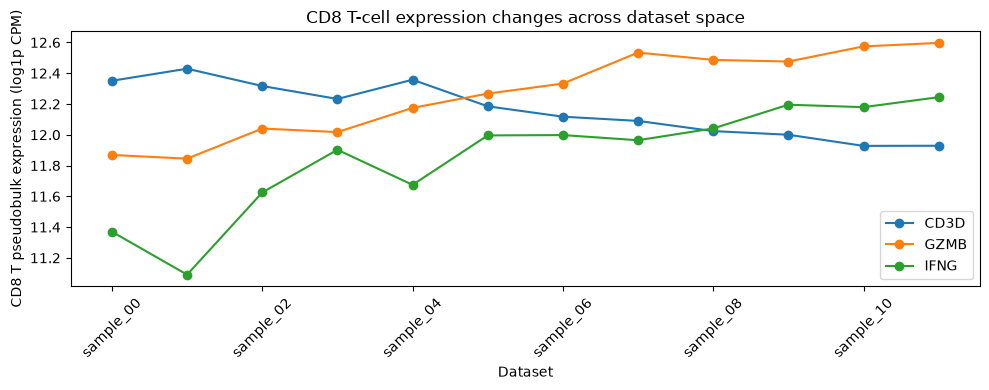

In [12]:
marker_genes = ["CD3D", "GZMB", "IFNG"]
cd8_expression_df = cd8_t_expression.to_df().loc[ordered_samples, marker_genes]

ax = cd8_expression_df.plot(marker="o", figsize=(10, 4))
ax.set_xlabel("Dataset")
ax.set_ylabel("CD8 T pseudobulk expression (log1p CPM)")
ax.set_title("CD8 T-cell expression changes across dataset space")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

In [13]:
immune_group_space.to_df().loc[ordered_samples].head()

immune_group,B/plasma,T/NK,granulocyte,myeloid
sample_id,,,,
sample_00,0.276636,0.480374,0.061682,0.181308
sample_01,0.098888,0.328801,0.072930,0.499382
sample_02,0.017836,0.634958,0.068966,0.278240
sample_03,0.342903,0.349282,0.033493,0.274322
sample_04,0.109827,0.493256,0.030829,0.366089


Each modality has the same dataset/sample observation axis as `dset.obs`, but a different feature axis. Here `cell_type_population` and `immune_group_population` describe composition, while `cd8_t_expression` stores a dataset-level gene-expression signature for one selected cell type.


In [14]:
dset.mod

MuData
├─ cell_type_population AnnData (12 x 10)
├─ immune_group_population AnnData (12 x 4)
└─ cd8_t_expression AnnData (12 x 12)